In [1]:
import numpy as np
import scipy.stats as ss
from scipy.optimize import brentq
import matplotlib.pyplot as plt
from tqdm import tqdm

# E-SR / E-CUSUM detectors

In [ ]:
# def bisection_method(func, a, b, eps):
#     func_a, func_b = func(a), func(b)
#     while np.abs(a - b) > eps:
#         mid = (a + b) / 2
#         func_mid = func(mid)
#         if (func_mid > 0 and func_a < 0) or (func_mid < 0 and func_a > 0):
#             b = mid
#             func_b = func_mid
#         else:
#             a = mid
#             func_a = func_mid
#     return (a + b) / 2

In [ ]:
def compute_threshold(alpha, delta_L, delta_U, K_max, psi_star, v_min):
    D_L = psi_star(delta_L)
    D_U = psi_star(delta_U)
    def f(g):
        ks = np.arange(1, K_max + 1)
        return np.min(ks * np.exp(-g*np.pow(D_U / D_L, -1/ks)))
    def f2(g):
        return f(g) - alpha
    if f(v_min * D_U) <= alpha:
        return brentq(f2, np.log(1/alpha), v_min * D_U)
        # return bisection_method(f2, np.log(1/alpha), v_min * D_U, eps)
    else:
        return brentq(f2, v_min * D_U, (D_U / D_L) * np.log(2/alpha))
        # return bisection_method(f2, v_min * D_U, (D_U / D_L) * np.log(2/alpha), eps)

In [ ]:
def compute_baseline(alpha, delta_L, delta_U, K_max, psi_star, psi_star_grad, v_min):
    D_L = psi_star(delta_L)
    D_U = psi_star(delta_U)
    lambda_L = psi_star_grad(delta_L)
    lambda_U = psi_star_grad(delta_U)
    if np.log(1/alpha) <= v_min * D_L:
        return np.array([lambda_L]), np.ones(1), None
    g_alpha = compute_threshold(alpha, delta_L, delta_U, K_max, psi_star, v_min)
    ks = np.arange(1, K_max + 1)
    K_alpha = np.argmin(ks * np.exp(-g_alpha * np.pow(D_U / D_L, -1/ks))) + 1
    eta_alpha = (D_U / D_L) ** (1 / K_alpha)
    lambdas = np.zeros(K_alpha + 1)
    lambdas[0] = lambda_U
    lambdas[K_alpha] = lambda_L
    for k in range(1, K_alpha):
        delta_k = brentq(lambda z: psi_star(z) - D_U * eta_alpha ** (-k), delta_L, delta_U)
        lambdas[k] = psi_star_grad(delta_k)
    W = np.exp(-g_alpha) * (1 if g_alpha > v_min * D_U else 0) + K_alpha * np.exp(-g_alpha / eta_alpha)
    omegas = np.zeros_like(lambdas)
    omegas[0] = (np.exp(-g_alpha) * (1 if g_alpha > v_min * D_U else 0)) / W
    for k in range(1, K_alpha + 1):
        omegas[k] = np.exp(-g_alpha / eta_alpha) / W

    return lambdas, omegas, (g_alpha, K_alpha, eta_alpha, W)


In [ ]:
class eSR_Mixture:
    def __init__(self, alpha, delta_L, delta_U, K_max, psi_func, psi_star_func, psi_star_grad, s_func, v_func, v_min):
        self.alpha = alpha
        lambdas, omegas, params = compute_baseline(alpha, delta_L, delta_U, K_max, psi_star_func, psi_star_grad, v_min)
        self.lambdas = lambdas
        self.omegas = omegas
        self.g_alpha = None
        self.eta_alpha = None
        self.W = None
        if params:
            self.g_alpha = params[0]
            self.eta_alpha = params[2]
            self.W = params[3]
        self.K_alpha = len(lambdas) - 1
        self.M_SR = np.zeros(self.K_alpha + 1)
        self.psi = np.array([psi_func(lam) for lam in self.lambdas])
        self.s_func = s_func
        self.v_func = v_func
        self.n = 0


    def observe(self, X):
        self.n += 1
        self.M_SR = np.exp(self.lambdas * self.s_func(X) - self.psi * self.v_func(X)) * (self.M_SR + 1)
        mM_SR = np.dot(self.omegas, self.M_SR)
        if mM_SR >= 1 / self.alpha:
            return self.n, mM_SR
        return None, mM_SR

class eCU_Mixture:
    def __init__(self, alpha, delta_L, delta_U, K_max, psi_func, psi_star_func, psi_star_grad, s_func, v_func, v_min):
        self.alpha = alpha
        lambdas, omegas, params = compute_baseline(alpha, delta_L, delta_U, K_max, psi_star_func, psi_star_grad, v_min)
        self.lambdas = lambdas
        self.omegas = omegas
        self.g_alpha = None
        self.eta_alpha = None
        self.W = None
        if params:
            self.g_alpha = params[0]
            self.eta_alpha = params[2]
            self.W = params[3]
        self.K_alpha = len(lambdas) - 1
        self.M_CU = np.zeros(self.K_alpha + 1)
        self.psi = np.array([psi_func(lam) for lam in self.lambdas])
        self.s_func = s_func
        self.v_func = v_func
        self.n = 0


    def observe(self, X):
        self.n += 1
        self.M_CU = np.exp(self.lambdas * self.s_func(X) - self.psi * self.v_func(X)) * np.max([self.M_CU, np.ones_like(self.M_CU)], axis=0)
        mM_CU = np.dot(self.omegas, self.M_CU)
        if mM_CU >= 1 / self.alpha:
            return self.n, mM_CU
        return None, mM_CU


### Bernoulli example

In [ ]:
alpha = 0.001
p = 0.49
delta_L= 0.02
delta_U = 0.41
K_max = 1000

In [ ]:
def make_psi_functions(p):
    def psi(x):
        return np.log(1 - p + p * np.exp(x)) - x * p
    def psi_star(delta):
        q = delta + p
        return q * np.log(q / p) + (1 - q) * np.log((1 - q) / (1 - p))
    def psi_star_grad(delta):
        q = delta + p
        return np.log(q / p) - np.log((1 - q) / (1 - p))
    def s(x):
        return x - p
    def v(x):
        return 1

    return psi, psi_star, psi_star_grad, s, v


psi_func, psi_star_func, psi_star_grad, s_func, v_func = make_psi_functions(p)

#### E-SR and E-CUSUM with no change in data

In [ ]:
pre_dist = lambda size, seed: np.random.default_rng(seed=seed).binomial(1, 0.49, size=size)
post_dist = lambda size, seed: np.random.default_rng(seed=seed).binomial(1, 0.51, size=size)

In [ ]:
def make_exp(pre_dist, post_dist=None, N=100, N_plot=5, n_parts_after_change=4, pre_data_len=400, seed=42):
    data_streams = np.zeros(shape=(N, pre_data_len * (n_parts_after_change + 1)))
    for step in range(N):
        pre_change_data = pre_dist(pre_data_len, seed + step)
        post_change_data = post_dist(pre_data_len * n_parts_after_change, seed + step) if post_dist is not None else pre_dist(pre_data_len * n_parts_after_change, seed + step)
        data_streams[step] = np.concat([pre_change_data, post_change_data])

    delays_SR = np.ones(N, dtype=int) * (pre_data_len * (n_parts_after_change + 1))
    delays_CU = np.ones(N, dtype=int) * (pre_data_len * (n_parts_after_change + 1))

    plt.axhline(y=1/alpha, linestyle='--', color='b', linewidth=1)

    for step in range(N):
        achieved_SR = False
        achieved_CU = False
        SR_detector = eSR_Mixture(alpha, delta_L, delta_U, K_max, psi_func, psi_star_func, psi_star_grad, s_func, v_func, v_min=1)
        CU_detector = eCU_Mixture(alpha, delta_L, delta_U, K_max, psi_func, psi_star_func, psi_star_grad, s_func, v_func, v_min=1)
        mMSRs = []
        mMCUs = []
        cmap_SR = plt.cm.Greens
        cmap_CU = plt.cm.Reds

        data_stream = data_streams[step]
        for i, result in enumerate(data_stream):
            decision_SR, mM_SR = SR_detector.observe(result)
            decision_CU, mM_CU = CU_detector.observe(result)
            if step < N_plot:
                mMSRs.append(mM_SR)
                mMCUs.append(mM_CU)

            if (not achieved_SR) and (decision_SR is not None):
                delays_SR[step] = decision_SR
                achieved_SR = True

            if (not achieved_CU) and (decision_CU is not None):
                delays_CU[step] = decision_CU
                achieved_CU = True

        if step < N_plot:
            plt.plot(np.arange(1, pre_data_len * (n_parts_after_change + 1)  + 1), mMSRs, color=cmap_SR(0.3 + step / N_plot * 0.7), linewidth=0.4, label='eSR' if step == N_plot - 1 else "")
            plt.plot(np.arange(1, pre_data_len * (n_parts_after_change + 1)  + 1), mMCUs, color=cmap_CU(0.3 + step / N_plot * 0.7), linewidth=0.4, label='eCUSUM' if step ==  N_plot - 1 else "")

    plt.yscale('log')
    plt.xlabel('Time')
    plt.ylabel('M_n')
    plt.title(f"Data with no change" if post_dist is None else f"Data with change after step {pre_data_len}")

    if post_dist is not None:
        delays_CU -= (pre_data_len + 1)
        delays_SR -= (pre_data_len + 1)

    plt.legend()
    plt.show()

    return delays_SR, delays_CU


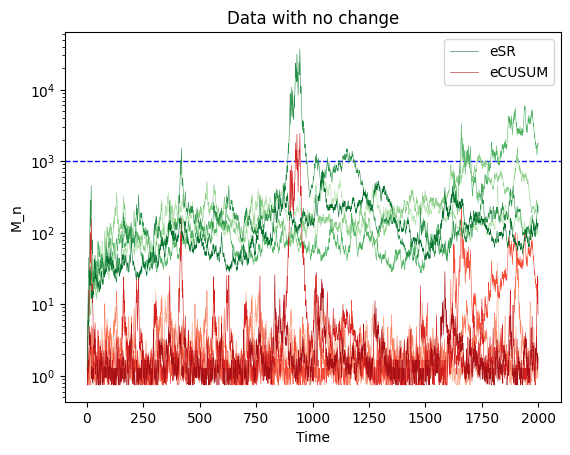

In [ ]:
delays_SR, delays_CU = make_exp(pre_dist)

In [ ]:
print(f"Average run length with eSR >= {delays_SR.mean()}")
print(f"Average run length with eCUSUM >= {delays_CU.mean()}")

Average run length with eSR >= 1076.91
Average run length with eCUSUM >= 1895.99


#### E-SR and E-CUSUM with change in data

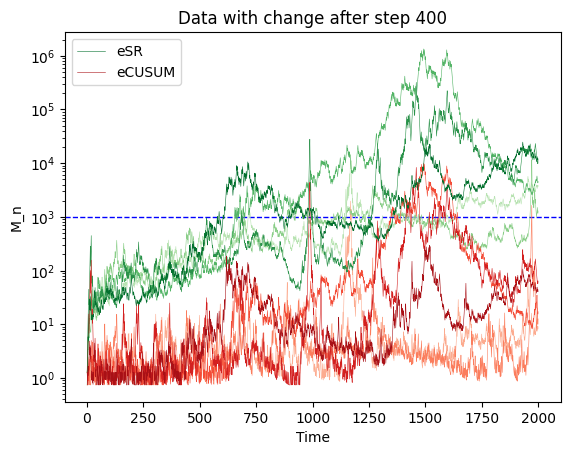

In [ ]:
delays_SR, delays_CU = make_exp(pre_dist, post_dist)

In [ ]:
print(f"Average delay with eSR >= {delays_SR.mean()}")
print(f"Average delay with eCUSUM >= {delays_CU.mean()}")

Average delay with eSR >= 249.12
Average delay with eCUSUM >= 1341.13


# Heavy-tailed distributions e-detector

$L_n = \exp \Big( \phi\big(\lambda_n(X_i - \mu)\big) - \lambda^2 \sigma^2 \Big)$

$\phi(x) = \begin{cases}
\log(1+x+\frac{x^2}{2}) & x \ge 0 \\
-\log(1-x+\frac{x^2}{2}) & x < 0
\end{cases}$

## Original way

In [7]:
class eSR_heavy_tailed:
    def __init__(self, alpha, data=None, mu=None, sigma2=None):
        self.alpha = alpha
        self.phi = lambda x: np.log(1 + x + x * x / 2) if x >= 0 else -np.log(1 - x + x * x / 2)
        self.mu = mu if mu is not None else data.mean()
        self.sigma2 = sigma2 if sigma2 is not None else data.var(ddof=1)
        self.lamb = 1
        self.eta2 = 0
        self.n = data.shape[0] if data is not None else 0
        self.e_SR = 0

    def observe(self, X):
        self.n += 1
        self.eta2 = (2 * self.sigma2 * np.log(2 / self.alpha)) / (self.n - 2 * np.log(2 / self.alpha))
        self.lamb = np.sqrt((2 * np.log(2 / self.alpha)) / (self.n * (self.sigma2 + self.eta2)))
        self.e_SR = np.exp(self.phi(self.lamb * (X - self.mu)) - self.lamb ** 2 * self.sigma2) * (self.e_SR + 1)
        if self.e_SR >= 1 / self.alpha:
            return self.n, self.e_SR
        return None, self.e_SR



## Simple way

In [8]:
class eSR_heavy_tailed_simple:
    def __init__(self, alpha, data=None, mu=None, sigma2=None):
        self.alpha = alpha
        self.phi = lambda x: np.log(1 + x + x * x / 2) if x >= 0 else -np.log(1 - x + x * x / 2)
        self.mu = mu if mu is not None else data.mean()
        self.sigma2 = sigma2 if sigma2 is not None else data.var(ddof=1)
        self.lamb = 1
        self.eta2 = 0
        self.n = data.shape[0] if data is not None else 0
        self.e_SR = 0

    def observe(self, X):
        self.n += 1
        # self.eta2 = (2 * self.sigma2 * np.log(2 / self.alpha)) / (self.n - 2 * np.log(2 / self.alpha))
        # self.lamb = np.sqrt((2 * np.log(2 / self.alpha)) / (self.n * (self.sigma2 + self.eta2)))
        self.lamb = 1 / np.sqrt(self.n)
        self.e_SR = np.exp(self.phi(self.lamb * (X - self.mu)) - self.lamb ** 2 * self.sigma2) * (self.e_SR + 1)
        if self.e_SR >= 1 / self.alpha:
            return self.n, self.e_SR
        return None, self.e_SR

In [9]:
class eSR_heavy_tailed_simple2:
    def __init__(self, alpha, data=None, mu=None, sigma2=None):
        self.alpha = alpha
        self.phi = lambda x: np.log(1 + x + x * x / 2) if x >= 0 else -np.log(1 - x + x * x / 2)
        self.mu = mu if mu is not None else data.mean()
        self.sigma2 = sigma2 if sigma2 is not None else data.var(ddof=1)
        self.lamb = 1
        self.eta2 = 0
        self.n = 0
        self.e_SR = 0

    def observe(self, X):
        self.n += 1
        # self.eta2 = (2 * self.sigma2 * np.log(2 / self.alpha)) / (self.n - 2 * np.log(2 / self.alpha))
        # self.lamb = np.sqrt((2 * np.log(2 / self.alpha)) / (self.n * (self.sigma2 + self.eta2)))
        self.lamb = 1 / np.sqrt(self.n)
        self.e_SR = np.exp(self.phi(self.lamb * (X - self.mu)) - self.lamb ** 2 * self.sigma2) * (self.e_SR + 1)
        if self.e_SR >= 1 / self.alpha:
            return self.n, self.e_SR
        return None, self.e_SR

In [10]:
class eSR_heavy_tailed_simple_robust:
    def __init__(self, alpha, data=None, mu=None, sigma2=None):
        self.alpha = alpha
        self.phi = lambda x: np.log(1 + x + x * x / 2) if x >= 0 else -np.log(1 - x + x * x / 2)
        quantiles = np.quantile(data, [0.05, 0.95])
        data_ = data[(quantiles[0] <= data) & (data <= quantiles[1])]
        self.mu = data_.mean()
        self.sigma2 = ss.iqr(data, scale='normal')
        self.lamb = 1
        self.eta2 = 0
        self.n = 0
        self.e_SR = 0

    def observe(self, X):
        self.n += 1
        # self.eta2 = (2 * self.sigma2 * np.log(2 / self.alpha)) / (self.n - 2 * np.log(2 / self.alpha))
        # self.lamb = np.sqrt((2 * np.log(2 / self.alpha)) / (self.n * (self.sigma2 + self.eta2)))
        self.lamb = 1 / np.sqrt(self.n)
        self.e_SR = np.exp(self.phi(self.lamb * (X - self.mu)) - self.lamb ** 2 * self.sigma2) * (self.e_SR + 1)
        if self.e_SR >= 1 / self.alpha:
            return self.n, self.e_SR
        return None, self.e_SR

## Experiments

#### Begin

In [11]:
# Загрузим все данные, если что-то сохраняли

delays_mean = np.load('data.npz')
delays_mean2 = np.load('data2.npz')
delays_mean3 = np.load('data3.npz')
delays_mean_old = np.load('data_old.npz')
delays_mean_nochange = np.load('data_nochange.npz')
delays_mean2_nochange = np.load('data2_nochange.npz')
delays_mean3_nochange = np.load('data3_nochange.npz')

no_norm_delays_mean = np.load('no_norm_data.npz')
no_norm_delays_mean2 = np.load('no_norm_data2.npz')
no_norm_delays_mean3 = np.load('no_norm_data3.npz')
no_norm_delays_mean_old = np.load('no_norm_data_old.npz')
no_norm_delays_mean_nochange = np.load('no_norm_data_nochange.npz')
no_norm_delays_mean2_nochange = np.load('no_norm_data2_nochange.npz')
no_norm_delays_mean3_nochange = np.load('no_norm_data3_nochange.npz')

In [12]:
changetimes = [50, 300]
init_data_lens = [30, 100]
deltas_mean = [0.2, 0.5, 1.5, 2.0]
seed = 159
alpha = 0.001
N = 1000
dists = ['normal', 'student', 'lognormal', 'exp', 'beta', 'bernoulli', 'gamma', 'laplace']

In [13]:
def run_experiments(detector, deltas_mean, changetimes, seed, init_data_lens, alpha=0.001, N = 10000):
    np.random.seed(seed)

    pre_dists = {
        'normal': lambda size: np.random.normal(0, 1, size=size),
        'student': lambda size: np.random.standard_t(df=2.5, size=size) / np.sqrt(5),
        'lognormal': lambda size: (np.random.lognormal(1, 1/2, size=size) - 3) / 1.6,
        'exp': lambda size: np.random.exponential(scale=1, size=size) - 1,
        'beta': lambda size: (np.random.beta(a=2, b=2, size=size) - 0.5) / (np.sqrt(5) / 10),
        'bernoulli': lambda size: (np.random.binomial(n=1, p=0.5, size=size) - 0.5) / 0.5,
        'gamma': lambda size: (np.random.gamma(shape=2, scale=1, size=size) - 2) / np.sqrt(2),
        'laplace': lambda size: np.random.laplace(loc=0, scale=(np.sqrt(2) / 2), size=size),
    }
    post_dists_mean = {
        'normal': lambda size, delta: np.random.normal(0, 1, size=size) + delta,
        'student': lambda size, delta: np.random.standard_t(df=2.5, size=size) / np.sqrt(5) + delta,
        'lognormal': lambda size, delta: (np.random.lognormal(1, 1/2, size=size) - 3) / 1.6 + delta,
        'exp': lambda size, delta: np.random.exponential(scale=1, size=size) - 1 + delta,
        'beta': lambda size, delta: (np.random.beta(a=2, b=2, size=size) - 0.5) / (np.sqrt(5) / 10) + delta,
        'bernoulli': lambda size, delta: (np.random.binomial(n=1, p=0.5, size=size) - 0.5) / 0.25 + delta,
        'gamma': lambda size, delta: (np.random.gamma(shape=2, scale=1, size=size) - 2) / np.sqrt(2) + delta,
        'laplace': lambda size, delta: np.random.laplace(loc=0, scale=(np.sqrt(2) / 2), size=size) + delta,
    }

    delays_mean = {k: np.zeros(shape=(len(changetimes), len(deltas_mean), len(init_data_lens), N), dtype=int) for k in pre_dists.keys()}
    for dist_name in post_dists_mean.keys():
        for i_changetime, changetime in enumerate(changetimes):
            pre_data_len = changetime
            for i_delta, delta in enumerate(deltas_mean):
                for i_idl, init_data_len in enumerate(init_data_lens):
                    for j in tqdm(range(N), desc=f'Running {dist_name} distribution with changetime at step {changetime}, with history_size={init_data_len}, with delta={delta}'):
                        SR_detector = detector(alpha, data=pre_dists[dist_name](init_data_len))
                        data_stream = np.concat([pre_dists[dist_name](pre_data_len), post_dists_mean[dist_name](pre_data_len, delta)], axis=-1)
                        i = 0
                        last_idx = data_stream.shape[0] - 1
                        while True:
                            decision_SR, eval = SR_detector.observe(data_stream[i])
                            i += 1
                            if decision_SR is not None:
                                delay = i - pre_data_len
                                delays_mean[dist_name][i_changetime][i_delta][i_idl][j] = max(delay, 0)
                                break
                            if i > last_idx:
                                data_stream = np.concat([data_stream, post_dists_mean[dist_name](pre_data_len, delta)], axis=-1)
                                last_idx += pre_data_len

    return delays_mean

In [15]:
def run_experiments_no_normalize(detector, deltas_mean, changetimes, seed, init_data_lens, alpha=0.001, N = 10000):
    np.random.seed(seed)

    pre_dists = {
        'normal': lambda size: np.random.normal(0, 1, size=size),
        'student': lambda size: np.random.standard_t(df=2.5, size=size),
        'lognormal': lambda size: np.random.lognormal(1, 1/2, size=size),
        'exp': lambda size: np.random.exponential(scale=1, size=size),
        'beta': lambda size: np.random.beta(a=2, b=2, size=size),
        'bernoulli': lambda size: np.random.binomial(n=1, p=0.5, size=size),
        'gamma': lambda size: np.random.gamma(shape=2, scale=1, size=size),
        'laplace': lambda size: np.random.laplace(loc=1, scale=1, size=size),
    }
    post_dists_mean = {
        'normal': lambda size, delta: np.random.normal(0, 1, size=size) + delta,
        'student': lambda size, delta:  np.random.standard_t(df=2.5, size=size) + delta,
        'lognormal': lambda size, delta: np.random.lognormal(1, 1/2, size=size) + delta,
        'exp': lambda size, delta: np.random.exponential(scale=1, size=size) + delta,
        'beta': lambda size, delta:  np.random.beta(a=2, b=2, size=size) + delta,
        'bernoulli': lambda size, delta: np.random.binomial(n=1, p=0.5, size=size) + delta,
        'gamma': lambda size, delta: np.random.gamma(shape=2, scale=1, size=size) + delta,
        'laplace': lambda size, delta: np.random.laplace(loc=1, scale=1, size=size) + delta,
    }

    delays_mean = {k: np.zeros(shape=(len(changetimes), len(deltas_mean), len(init_data_lens), N), dtype=int) for k in pre_dists.keys()}
    for dist_name in post_dists_mean.keys():
        for i_changetime, changetime in enumerate(changetimes):
            pre_data_len = changetime
            for i_delta, delta in enumerate(deltas_mean):
                for i_idl, init_data_len in enumerate(init_data_lens):
                    for j in tqdm(range(N), desc=f'Running {dist_name} distribution with changetime at step {changetime}, with history_size={init_data_len}, with delta={delta}'):
                        SR_detector = detector(alpha, data=pre_dists[dist_name](init_data_len))
                        data_stream = np.concat([pre_dists[dist_name](pre_data_len), post_dists_mean[dist_name](pre_data_len, delta)], axis=-1)
                        i = 0
                        last_idx = data_stream.shape[0] - 1
                        while True:
                            decision_SR, eval = SR_detector.observe(data_stream[i])
                            i += 1
                            if decision_SR is not None:
                                delay = i - pre_data_len
                                delays_mean[dist_name][i_changetime][i_delta][i_idl][j] = max(delay, 0)
                                break
                            if i > last_idx:
                                data_stream = np.concat([data_stream, post_dists_mean[dist_name](pre_data_len, delta)], axis=-1)
                                last_idx += pre_data_len
                            if i > 100_000:
                                delays_mean[dist_name][i_changetime][i_delta][i_idl][j] = i - pre_data_len
                                break
    return delays_mean

In [16]:
def arl_check(no_change_data):
    print(f"Required average run length is {1/alpha}\n")
    flag = True
    for dist_name in dists:
        for i_idl, init_data_len in enumerate(init_data_lens):
            arl = no_change_data[dist_name][0][0][i_idl].mean()
            if arl < 1/alpha:
                flag=False
            print(f"Average run length with {dist_name} distribution and history_size={init_data_len} is {round(arl, 3)}")

    print()
    if flag:
        print("Average run length is as big as required with each distribution and history size")
    else:
        print("There are some problems with ARL")

#### On normalized distributions

In [ ]:
delays_mean = run_experiments(eSR_heavy_tailed_simple, deltas_mean, changetimes, seed, init_data_lens, alpha, N)

In [ ]:
delays_mean2 = run_experiments(eSR_heavy_tailed_simple2, deltas_mean, changetimes, seed, init_data_lens, alpha, N)

In [ ]:
delays_mean3 = run_experiments(eSR_heavy_tailed_simple_robust, deltas_mean, changetimes, seed, init_data_lens, alpha, N)

In [ ]:
delays_mean_old = run_experiments(eSR_heavy_tailed, deltas_mean, changetimes, seed, init_data_lens, alpha, N)

In [ ]:
delays_mean_nochange = run_experiments(eSR_heavy_tailed_simple, [0], [50], seed, init_data_lens, alpha, N)

In [ ]:
delays_mean2_nochange = run_experiments(eSR_heavy_tailed_simple2, [0], [50], seed, init_data_lens, alpha, N)

In [ ]:
delays_mean3_nochange = run_experiments(eSR_heavy_tailed_simple_robust, [0], [50], seed, init_data_lens, alpha, N)

In [6]:
arl_check(delays_mean_nochange)

Required average run length is 1000.0

Average run length with normal distribution and history_size=30 is 13242.159
Average run length with normal distribution and history_size=100 is 4220.055
Average run length with student distribution and history_size=30 is 12273.792
Average run length with student distribution and history_size=100 is 3782.255
Average run length with lognormal distribution and history_size=30 is 15155.177
Average run length with lognormal distribution and history_size=100 is 4405.629
Average run length with exp distribution and history_size=30 is 14070.934
Average run length with exp distribution and history_size=100 is 4686.581
Average run length with beta distribution and history_size=30 is 12656.506
Average run length with beta distribution and history_size=100 is 4328.014
Average run length with bernoulli distribution and history_size=30 is 6969.152
Average run length with bernoulli distribution and history_size=100 is 1461.831
Average run length with gamma dist

In [21]:
arl_check(delays_mean2_nochange)

Required average run length is 1000.0

Average run length with normal distribution and history_size=30 is 13292.546
Average run length with normal distribution and history_size=100 is 4487.364
Average run length with student distribution and history_size=30 is 12156.615
Average run length with student distribution and history_size=100 is 4201.876
Average run length with lognormal distribution and history_size=30 is 12929.496
Average run length with lognormal distribution and history_size=100 is 4993.964
Average run length with exp distribution and history_size=30 is 15846.97
Average run length with exp distribution and history_size=100 is 4468.576
Average run length with beta distribution and history_size=30 is 12749.831
Average run length with beta distribution and history_size=100 is 4592.395
Average run length with bernoulli distribution and history_size=30 is 7121.117
Average run length with bernoulli distribution and history_size=100 is 1578.39
Average run length with gamma distri

In [12]:
arl_check(delays_mean3_nochange)

Required average run length is 1000.0

Average run length with normal distribution and history_size=30 is 14596.646
Average run length with normal distribution and history_size=100 is 4486.245
Average run length with student distribution and history_size=30 is 5287.469
Average run length with student distribution and history_size=100 is 2015.104
Average run length with lognormal distribution and history_size=30 is 5432.718
Average run length with lognormal distribution and history_size=100 is 1112.584
Average run length with exp distribution and history_size=30 is 4155.122
Average run length with exp distribution and history_size=100 is 985.199
Average run length with beta distribution and history_size=30 is 13845.482
Average run length with beta distribution and history_size=100 is 4436.347
Average run length with bernoulli distribution and history_size=30 is 7411.988
Average run length with bernoulli distribution and history_size=100 is 1827.429
Average run length with gamma distribu

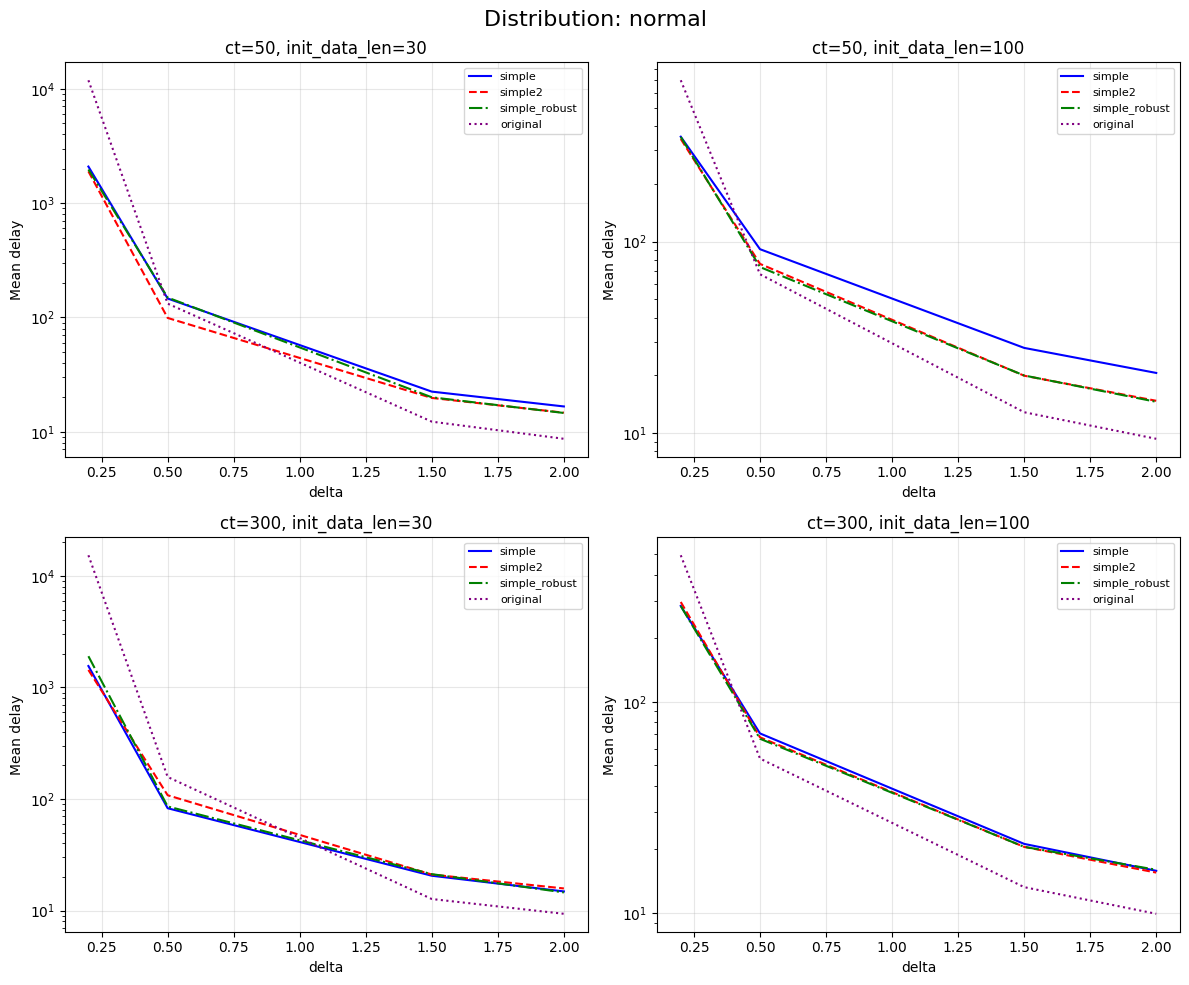

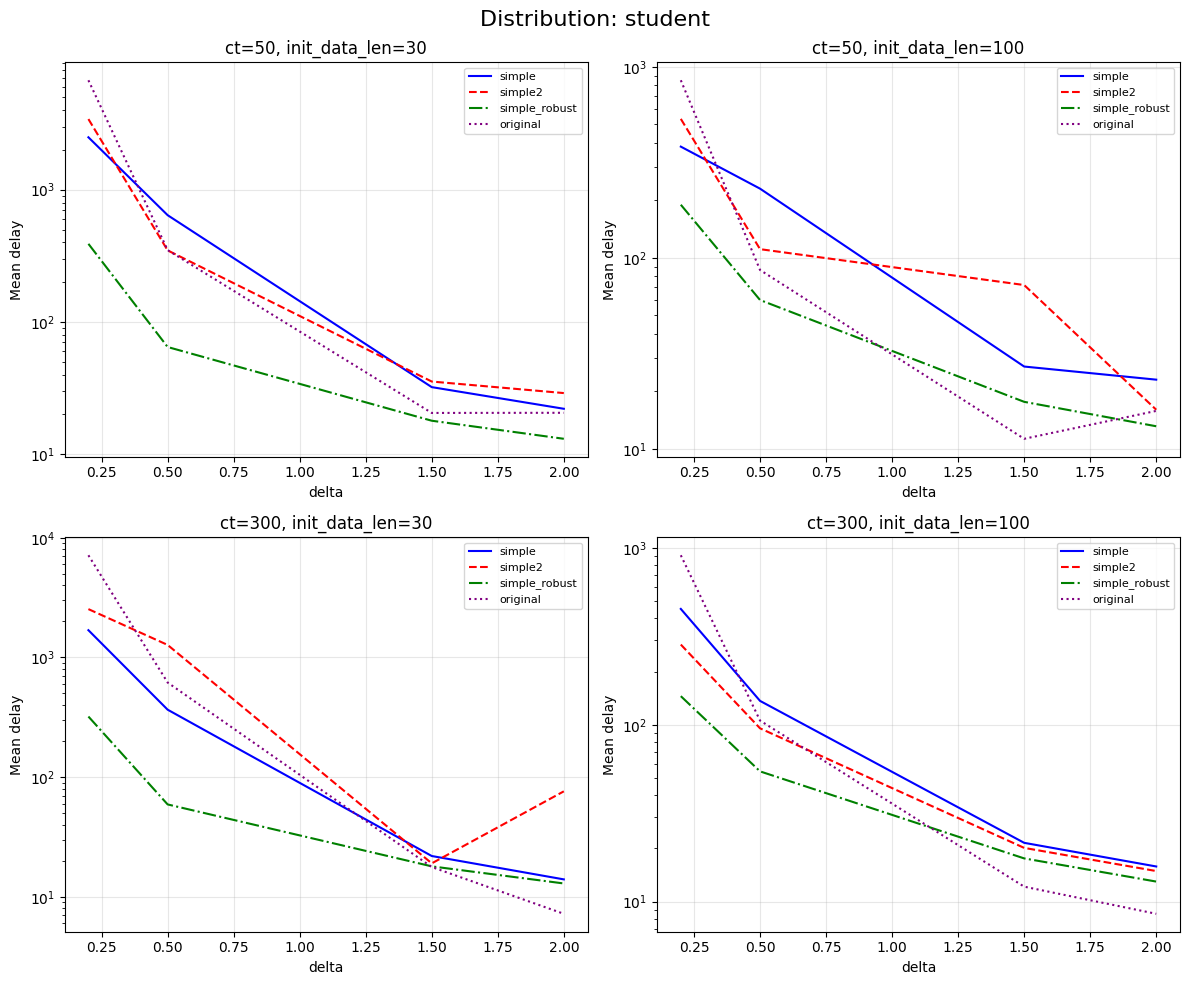

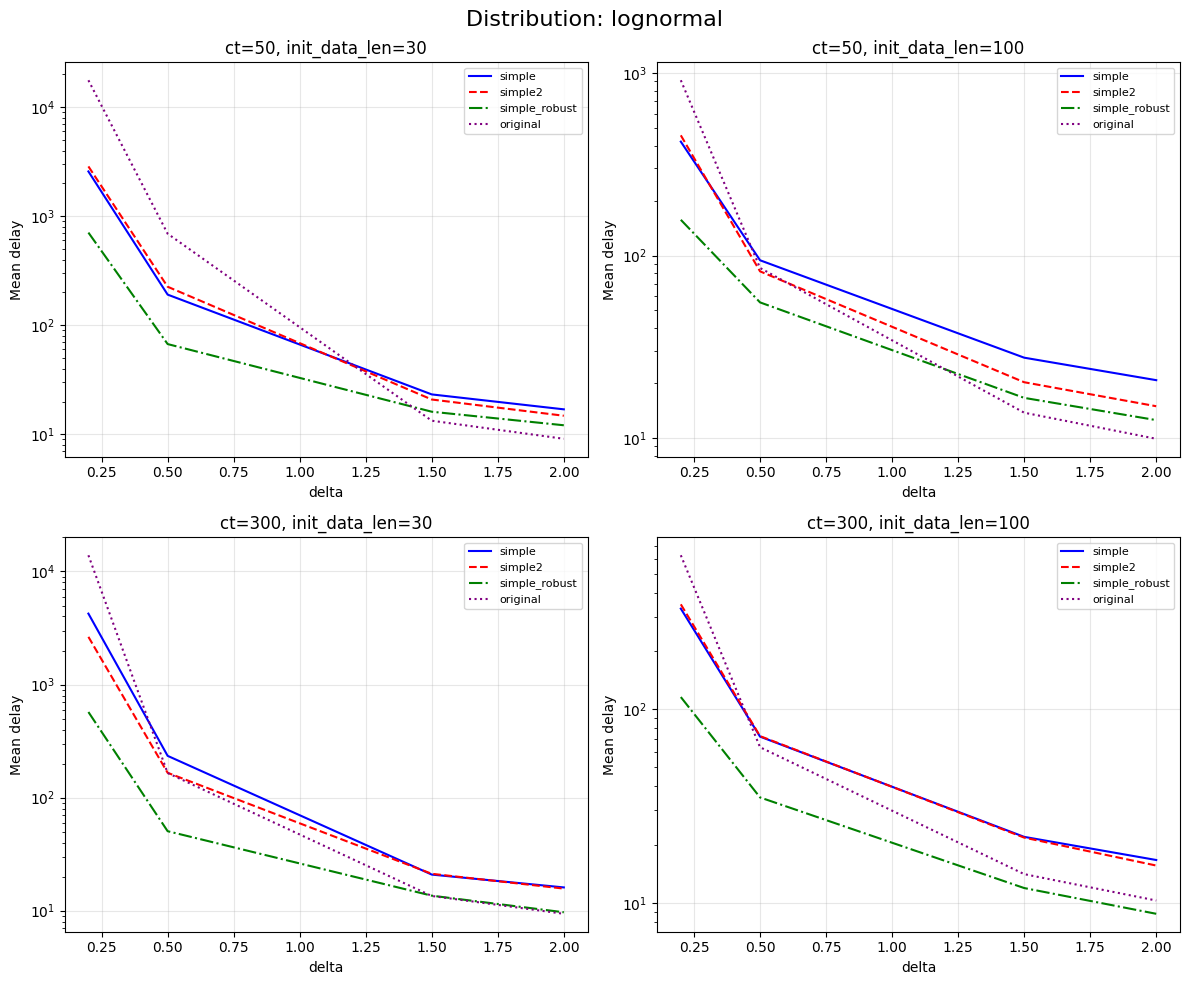

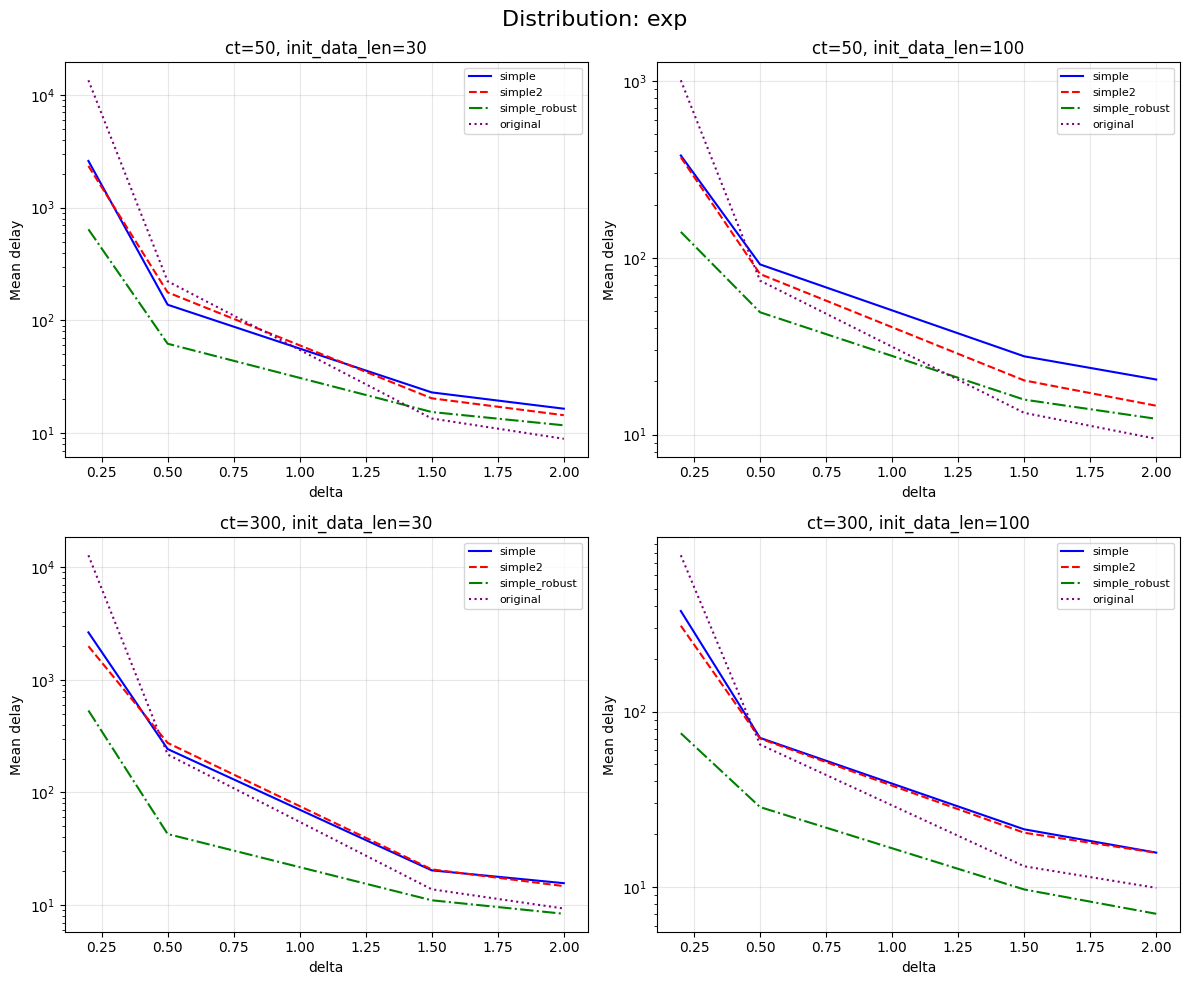

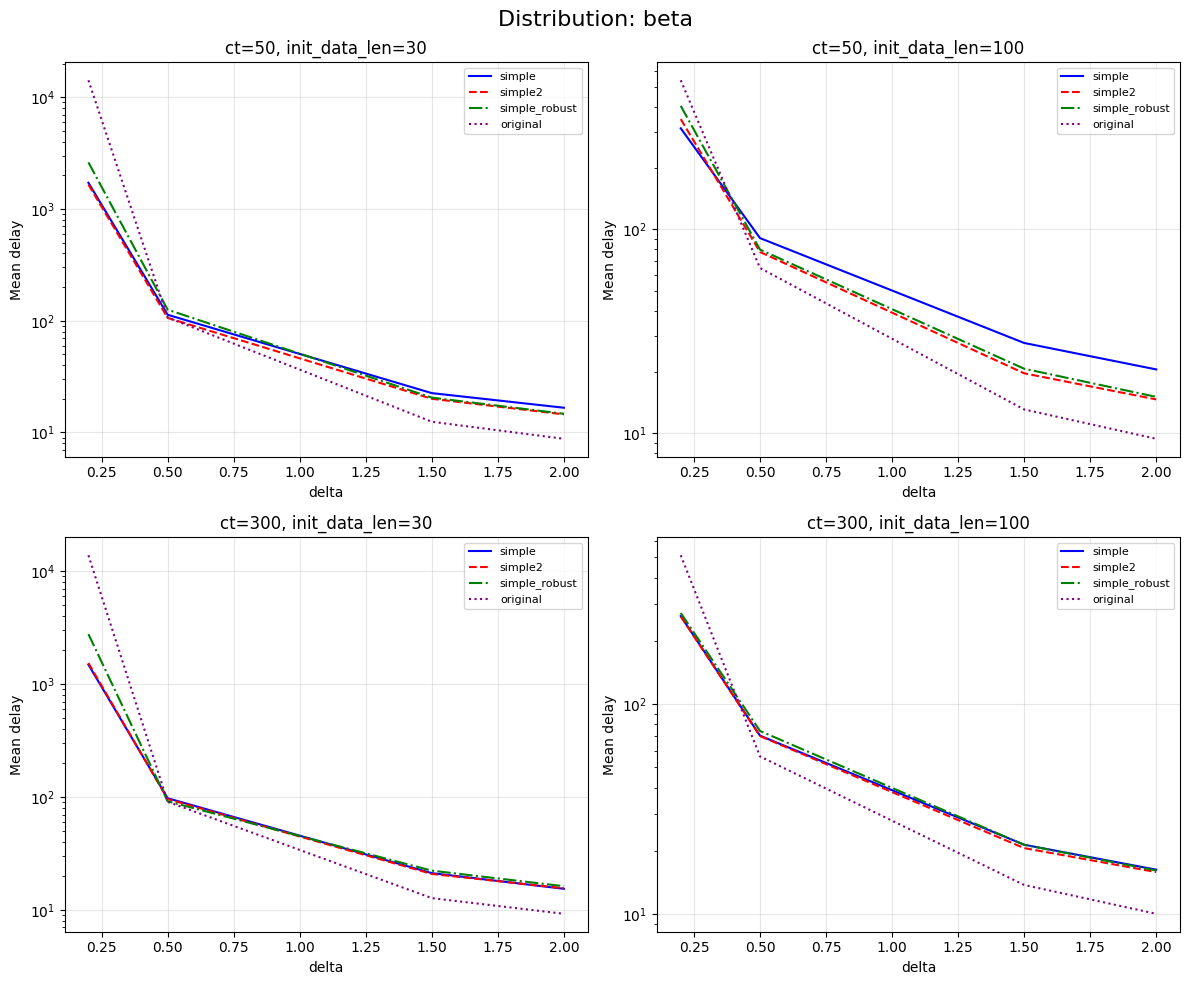

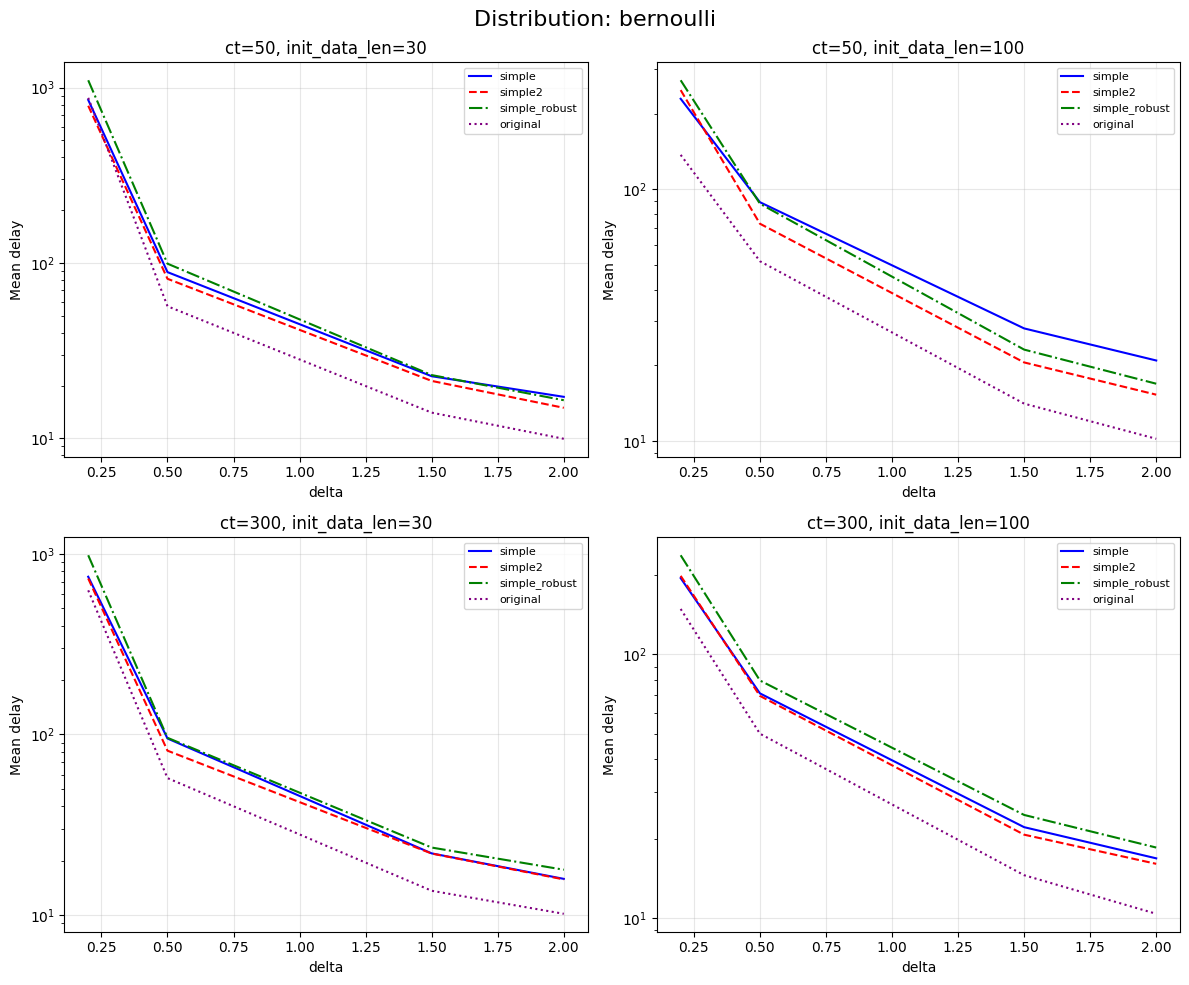

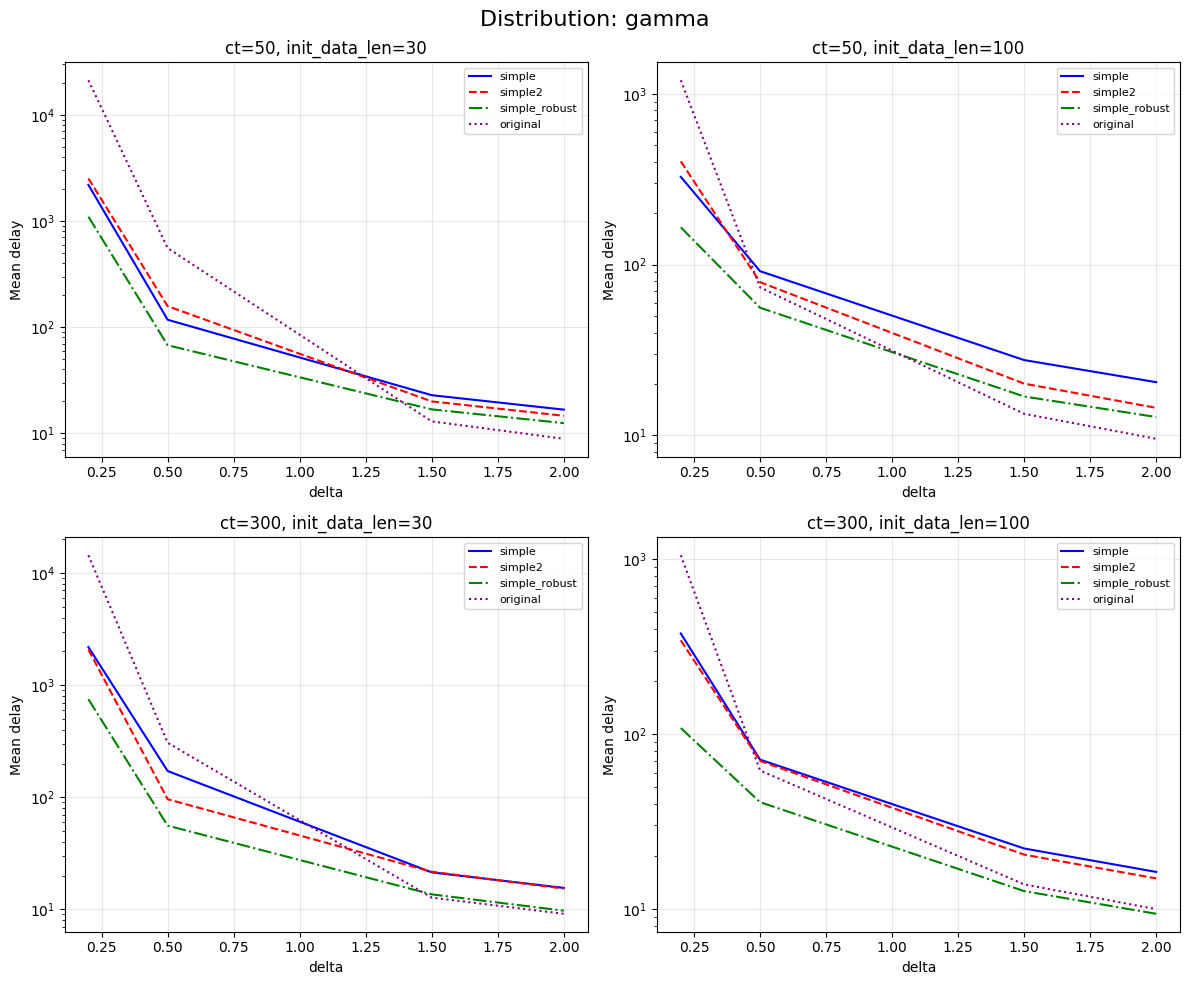

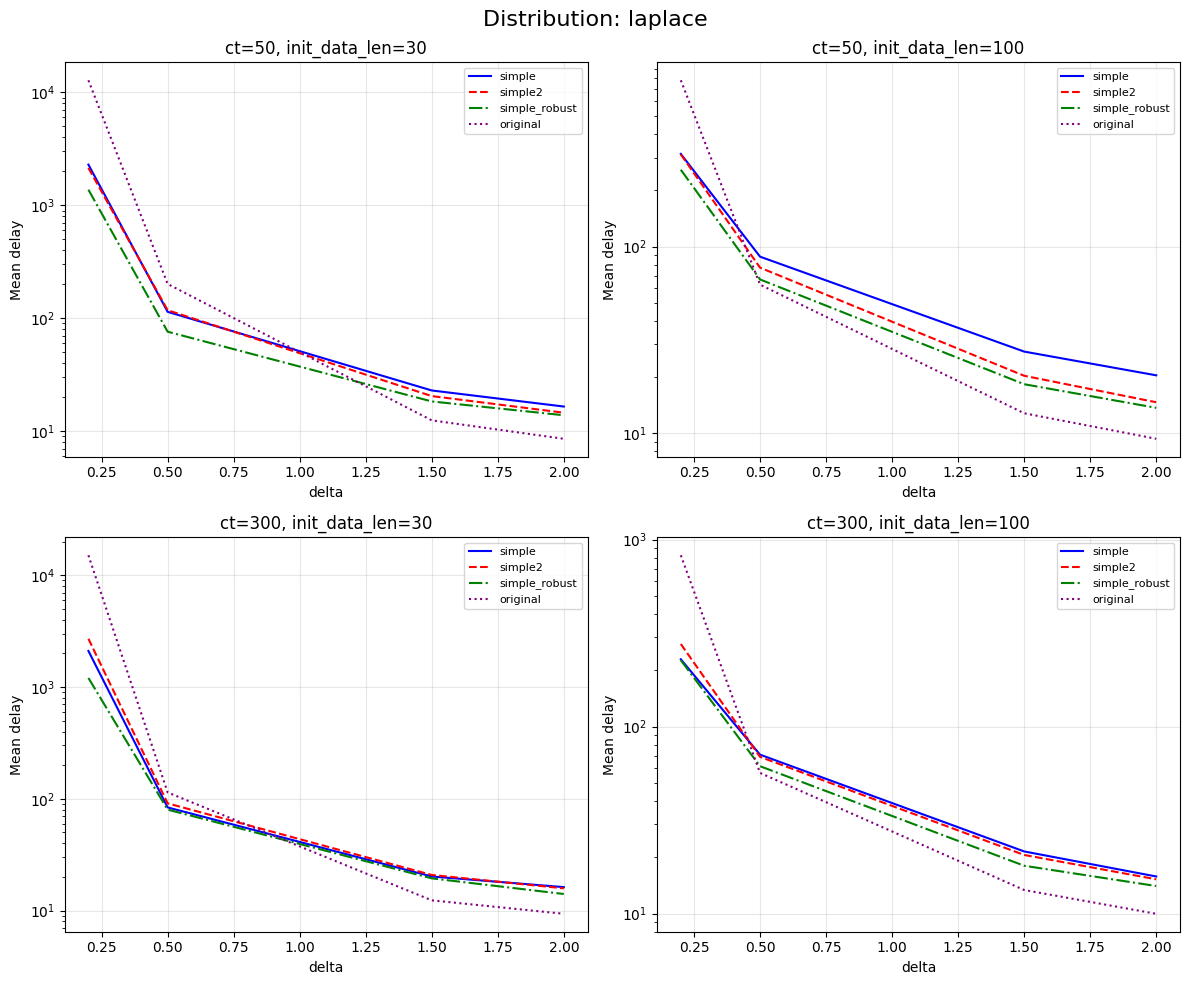

In [19]:
import matplotlib.pyplot as plt
import numpy as np

colors_methods = ['blue', 'red', 'green', 'purple']   # для simple, simple2, simple_robust, original
linestyles = ['solid', 'dashed', 'dashdot', 'dotted']
labels_methods = ['simple', 'simple2', 'simple_robust', 'original']

for dist_name in dists:
    data_dict = delays_mean[dist_name]       # (len(ct), len(delta), len(idl), N)
    data2_dict = delays_mean2[dist_name]
    data3_dict = delays_mean3[dist_name]
    old_data_dict = delays_mean_old[dist_name]

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'Distribution: {dist_name}', fontsize=16)

    for i, ct in enumerate(changetimes):
        for j, idl in enumerate(init_data_lens):
            ax = axes[i, j]

            data = data_dict[i, :, j, :]          # (len(deltas_mean), N)
            data2 = data2_dict[i, :, j, :]
            data3 = data3_dict[i, :, j, :]
            data_old = old_data_dict[i, :, j, :]

            mean_vals = np.mean(data, axis=1)
            mean_vals2 = np.mean(data2, axis=1)
            mean_vals3 = np.mean(data3, axis=1)
            mean_vals_old = np.mean(data_old, axis=1)

            # Построение четырёх кривых
            ax.plot(deltas_mean, mean_vals,
                    color=colors_methods[0], linestyle=linestyles[0],
                    linewidth=1.5, label=labels_methods[0])
            ax.plot(deltas_mean, mean_vals2,
                    color=colors_methods[1], linestyle=linestyles[1],
                    linewidth=1.5, label=labels_methods[1])
            ax.plot(deltas_mean, mean_vals3,
                    color=colors_methods[2], linestyle=linestyles[2],
                    linewidth=1.5, label=labels_methods[2])
            ax.plot(deltas_mean, mean_vals_old,
                    color=colors_methods[3], linestyle=linestyles[3],
                    linewidth=1.5, label=labels_methods[3])

            ax.set_title(f'ct={ct}, init_data_len={idl}')
            ax.set_xlabel('delta')
            ax.set_ylabel('Mean delay')
            ax.set_yscale('log')
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(f"mean_delays_{dist_name}.png")
    plt.show()

#### On not normalized distributions

In [ ]:
no_norm_delays_mean = run_experiments_no_normalize(eSR_heavy_tailed_simple, deltas_mean, changetimes, seed, init_data_lens, alpha, N)

In [ ]:
no_norm_delays_mean2 = run_experiments_no_normalize(eSR_heavy_tailed_simple2, deltas_mean, changetimes, seed, init_data_lens, alpha, N)

In [ ]:
no_norm_delays_mean3 = run_experiments_no_normalize(eSR_heavy_tailed_simple_robust, deltas_mean, changetimes, seed, init_data_lens, alpha, N)

In [ ]:
no_norm_delays_mean_old = run_experiments_no_normalize(eSR_heavy_tailed, deltas_mean, changetimes, seed, init_data_lens, alpha, N)

In [ ]:
no_norm_delays_mean_nochange = run_experiments_no_normalize(eSR_heavy_tailed_simple, [0], [50], seed, init_data_lens, alpha, N)

In [ ]:
no_norm_delays_mean2_nochange = run_experiments_no_normalize(eSR_heavy_tailed_simple2, [0], [50], seed, init_data_lens, alpha, N)

In [ ]:
no_norm_delays_mean3_nochange = run_experiments_no_normalize(eSR_heavy_tailed_simple_robust, [0], [50], seed, init_data_lens, alpha, N)

In [17]:
arl_check(no_norm_delays_mean_nochange)

Required average run length is 1000.0

Average run length with normal distribution and history_size=30 is 12579.252
Average run length with normal distribution and history_size=100 is 4341.787
Average run length with student distribution and history_size=30 is 18718.103
Average run length with student distribution and history_size=100 is 10163.092
Average run length with lognormal distribution and history_size=30 is 19536.112
Average run length with lognormal distribution and history_size=100 is 8020.607
Average run length with exp distribution and history_size=30 is 10477.545
Average run length with exp distribution and history_size=100 is 4310.513
Average run length with beta distribution and history_size=30 is 1615.489
Average run length with beta distribution and history_size=100 is 1150.117
Average run length with bernoulli distribution and history_size=30 is 4267.976
Average run length with bernoulli distribution and history_size=100 is 1873.175
Average run length with gamma dist

In [18]:
arl_check(no_norm_delays_mean2_nochange)

Required average run length is 1000.0

Average run length with normal distribution and history_size=30 is 10695.632
Average run length with normal distribution and history_size=100 is 4409.731
Average run length with student distribution and history_size=30 is 17073.263
Average run length with student distribution and history_size=100 is 9791.353
Average run length with lognormal distribution and history_size=30 is 16896.809
Average run length with lognormal distribution and history_size=100 is 8558.1
Average run length with exp distribution and history_size=30 is 11806.836
Average run length with exp distribution and history_size=100 is 4243.846
Average run length with beta distribution and history_size=30 is 1696.2
Average run length with beta distribution and history_size=100 is 1191.901
Average run length with bernoulli distribution and history_size=30 is 4228.76
Average run length with bernoulli distribution and history_size=100 is 1913.056
Average run length with gamma distributi

In [19]:
arl_check(no_norm_delays_mean3_nochange)

Required average run length is 1000.0

Average run length with normal distribution and history_size=30 is 13051.011
Average run length with normal distribution and history_size=100 is 4366.031
Average run length with student distribution and history_size=30 is 11383.469
Average run length with student distribution and history_size=100 is 2766.258
Average run length with lognormal distribution and history_size=30 is 7894.977
Average run length with lognormal distribution and history_size=100 is 1812.711
Average run length with exp distribution and history_size=30 is 4112.393
Average run length with exp distribution and history_size=100 is 893.831
Average run length with beta distribution and history_size=30 is 1937.049
Average run length with beta distribution and history_size=100 is 1412.882
Average run length with bernoulli distribution and history_size=30 is 4641.677
Average run length with bernoulli distribution and history_size=100 is 2349.875
Average run length with gamma distribu

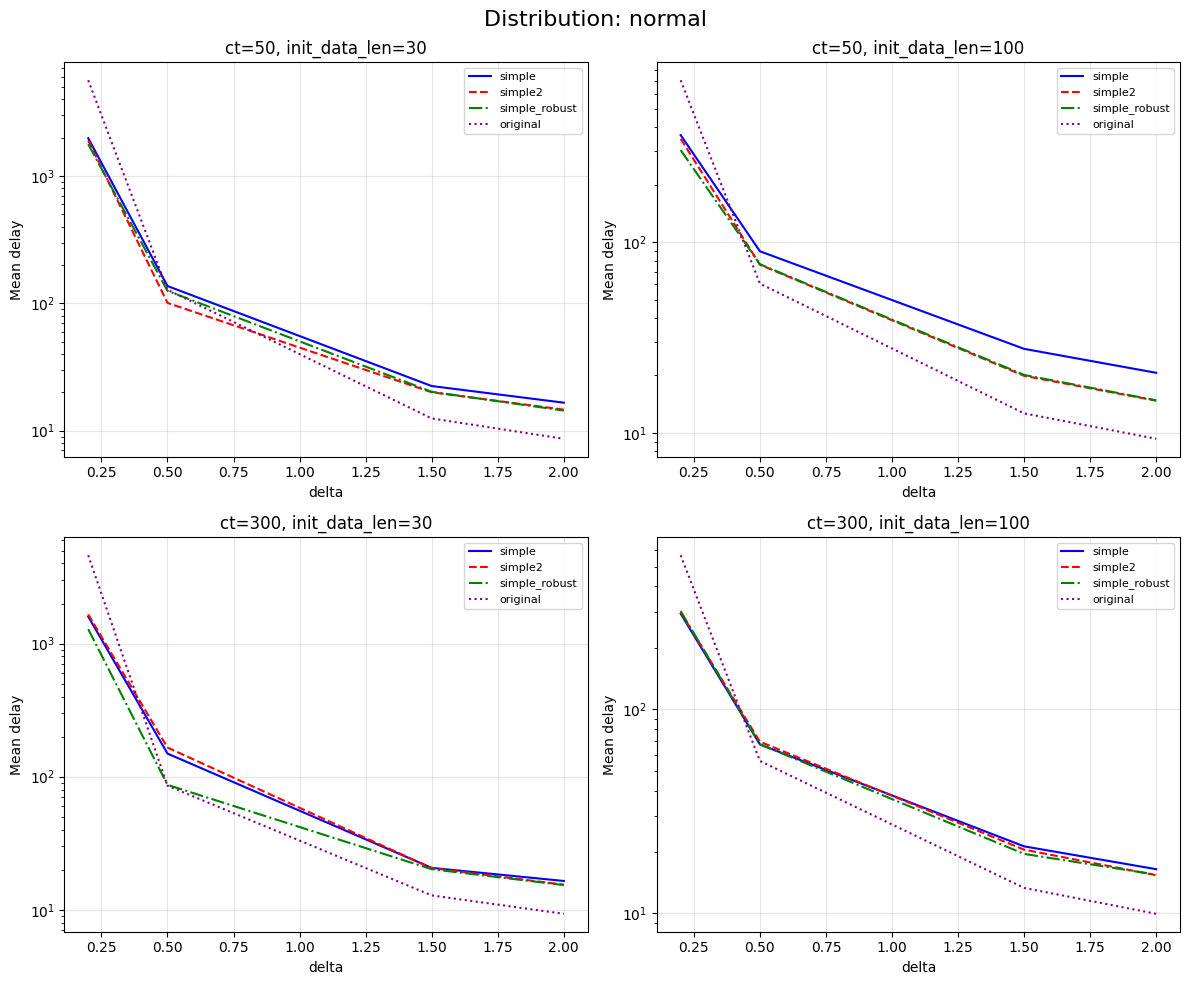

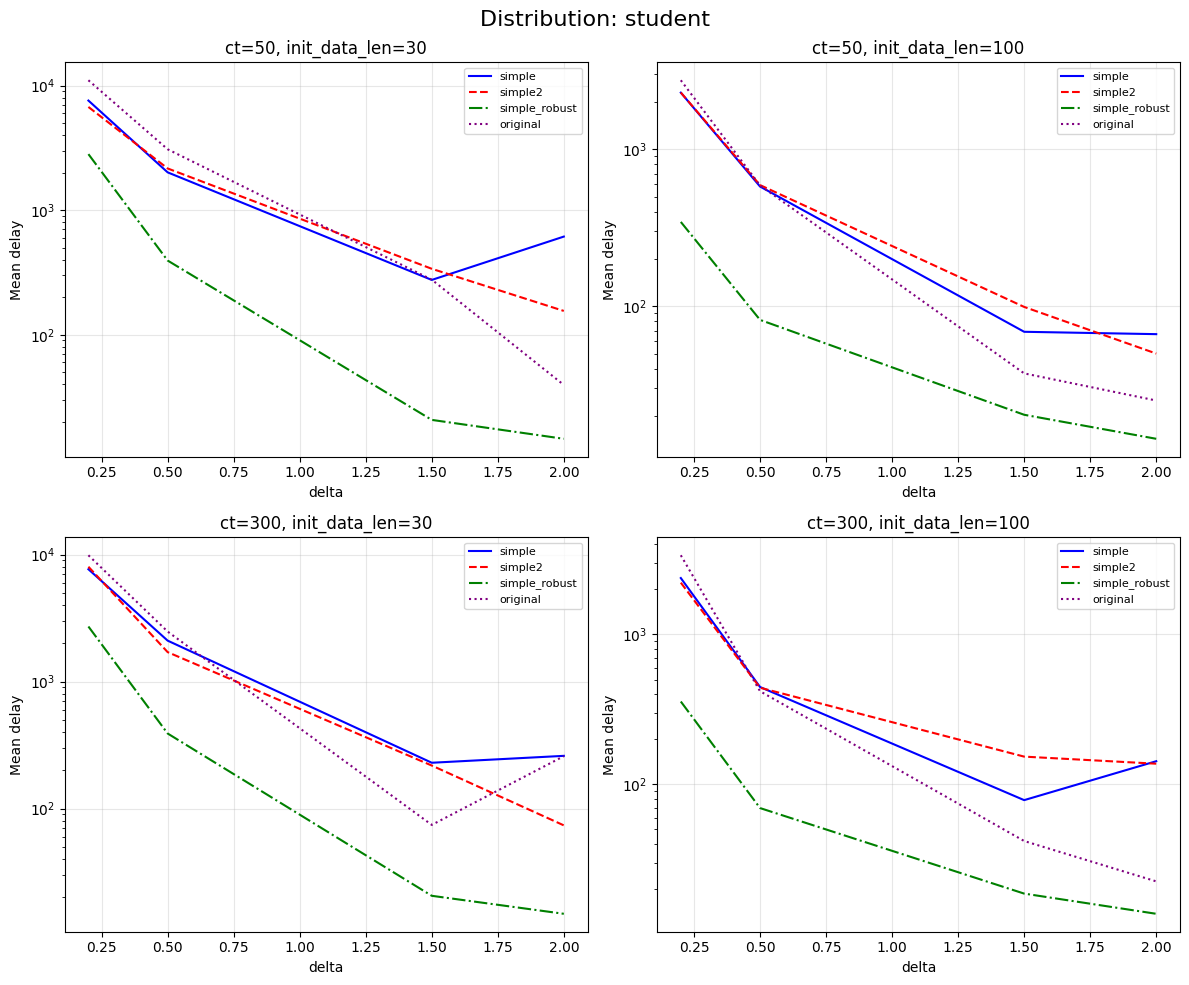

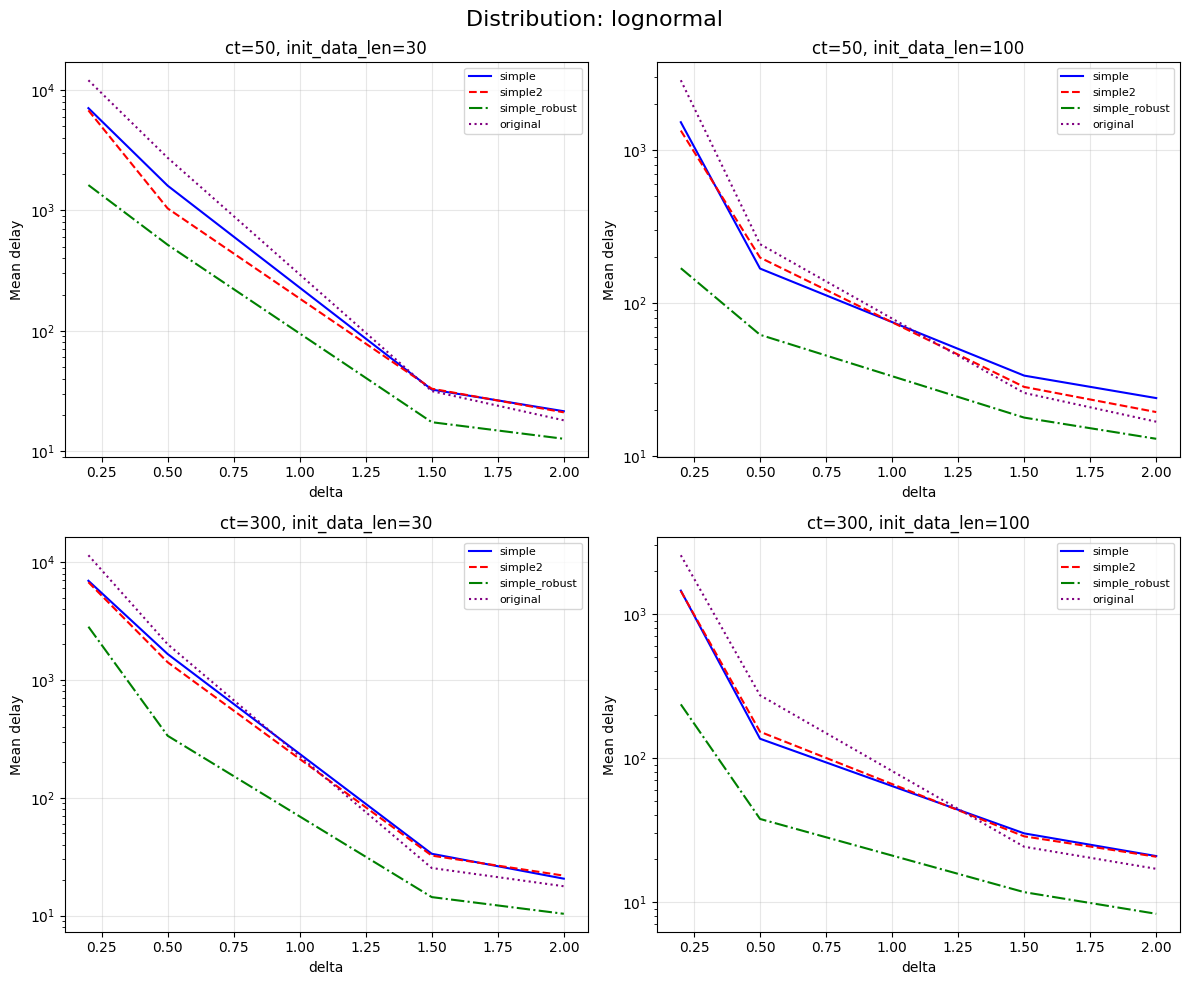

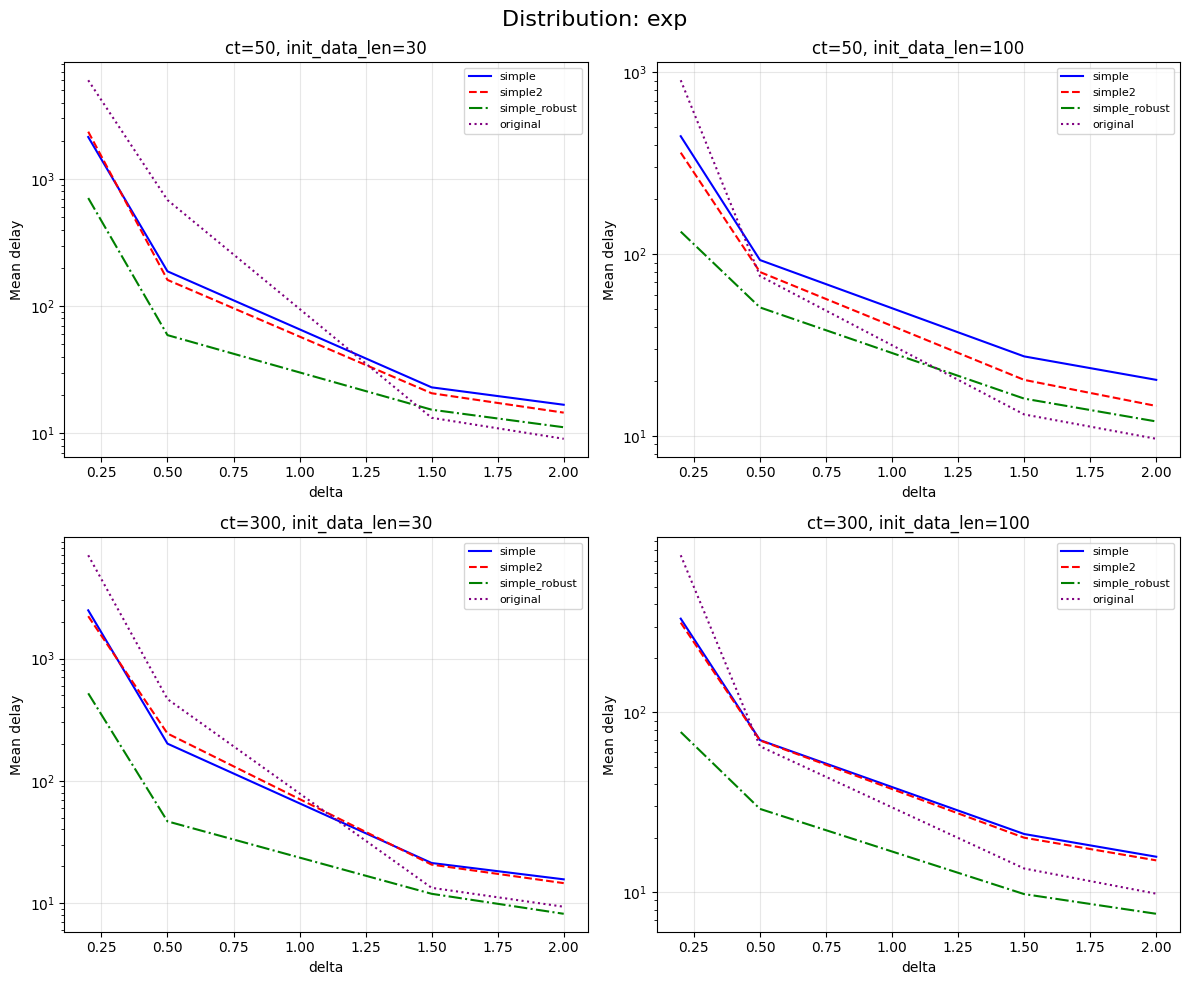

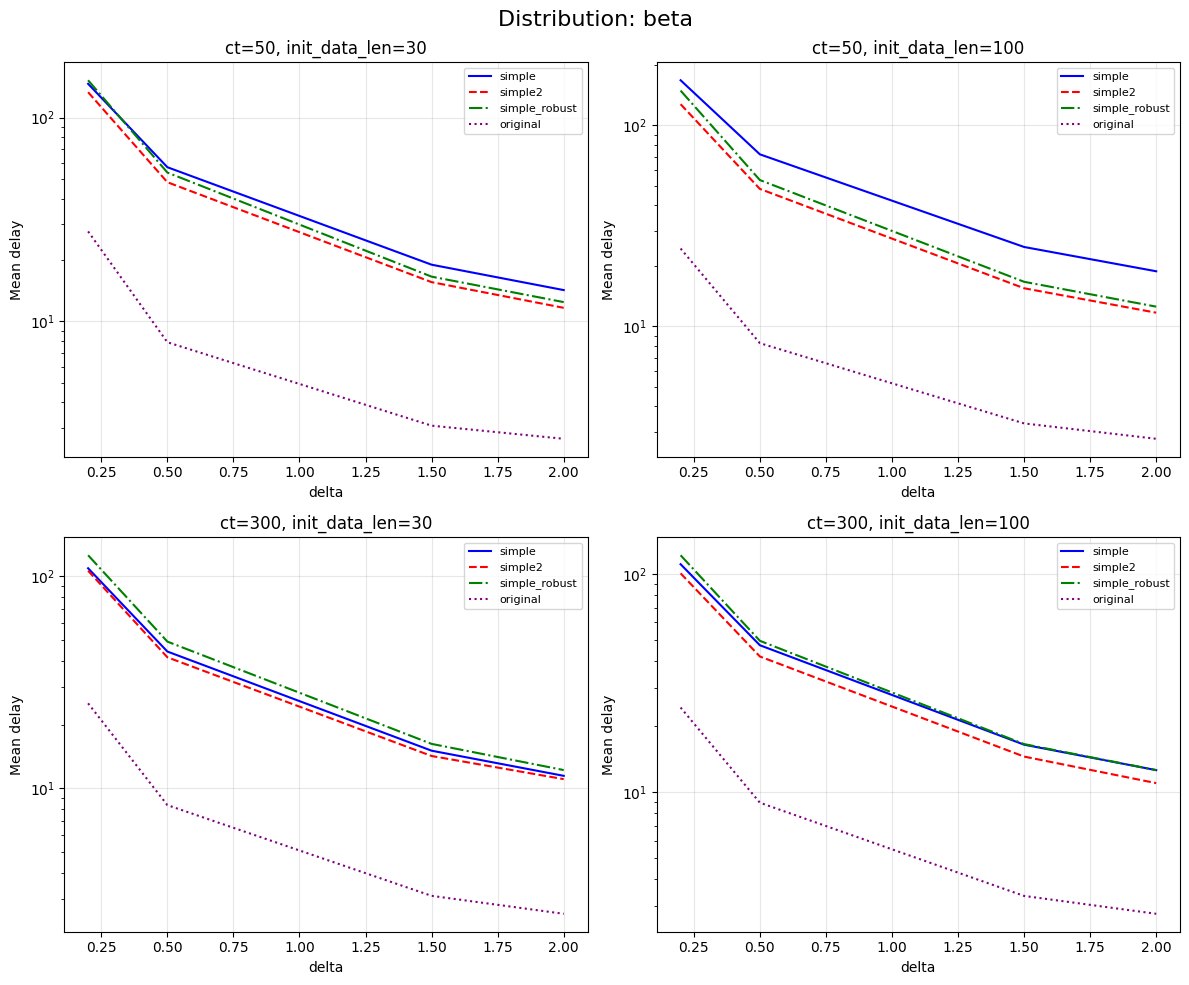

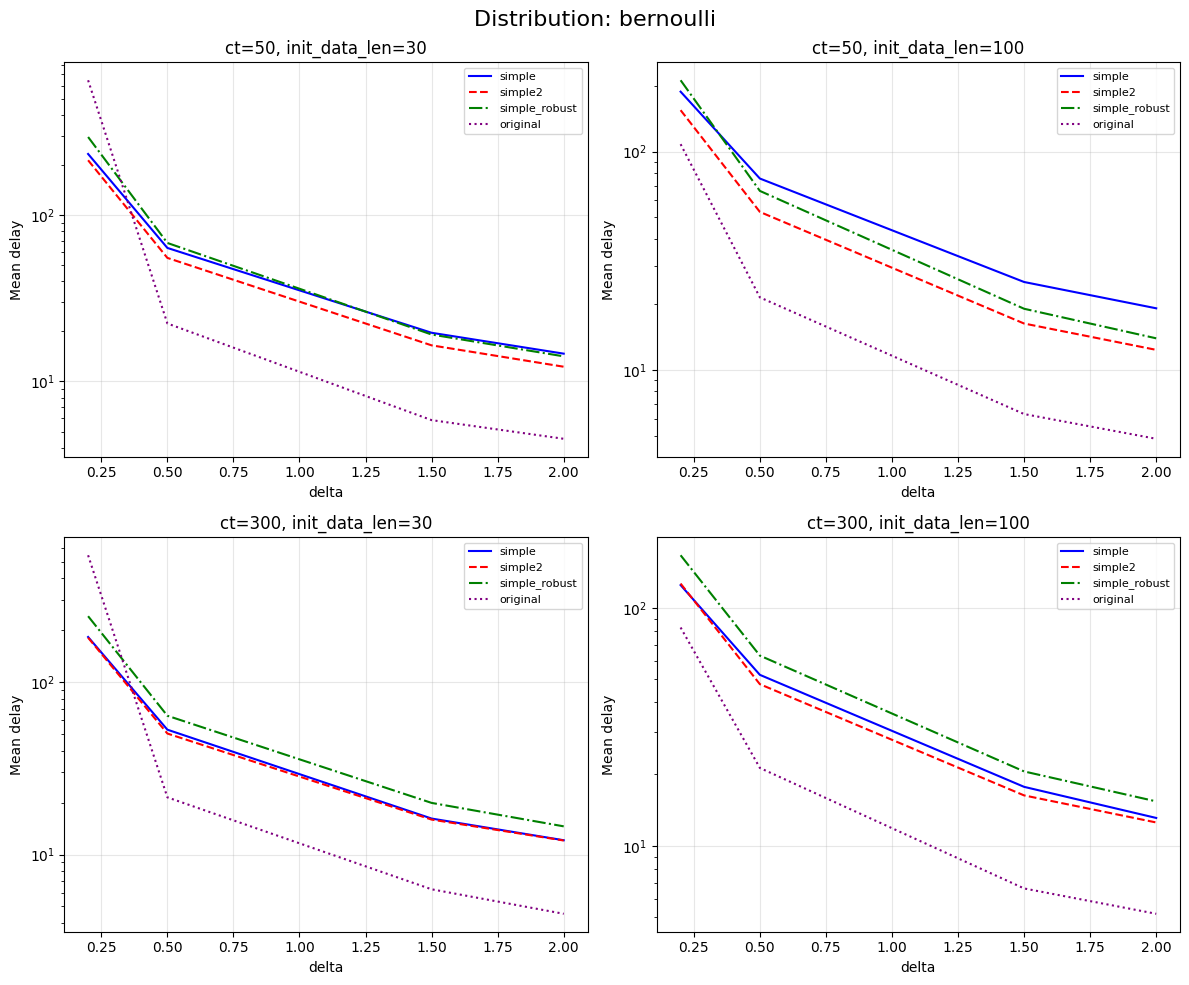

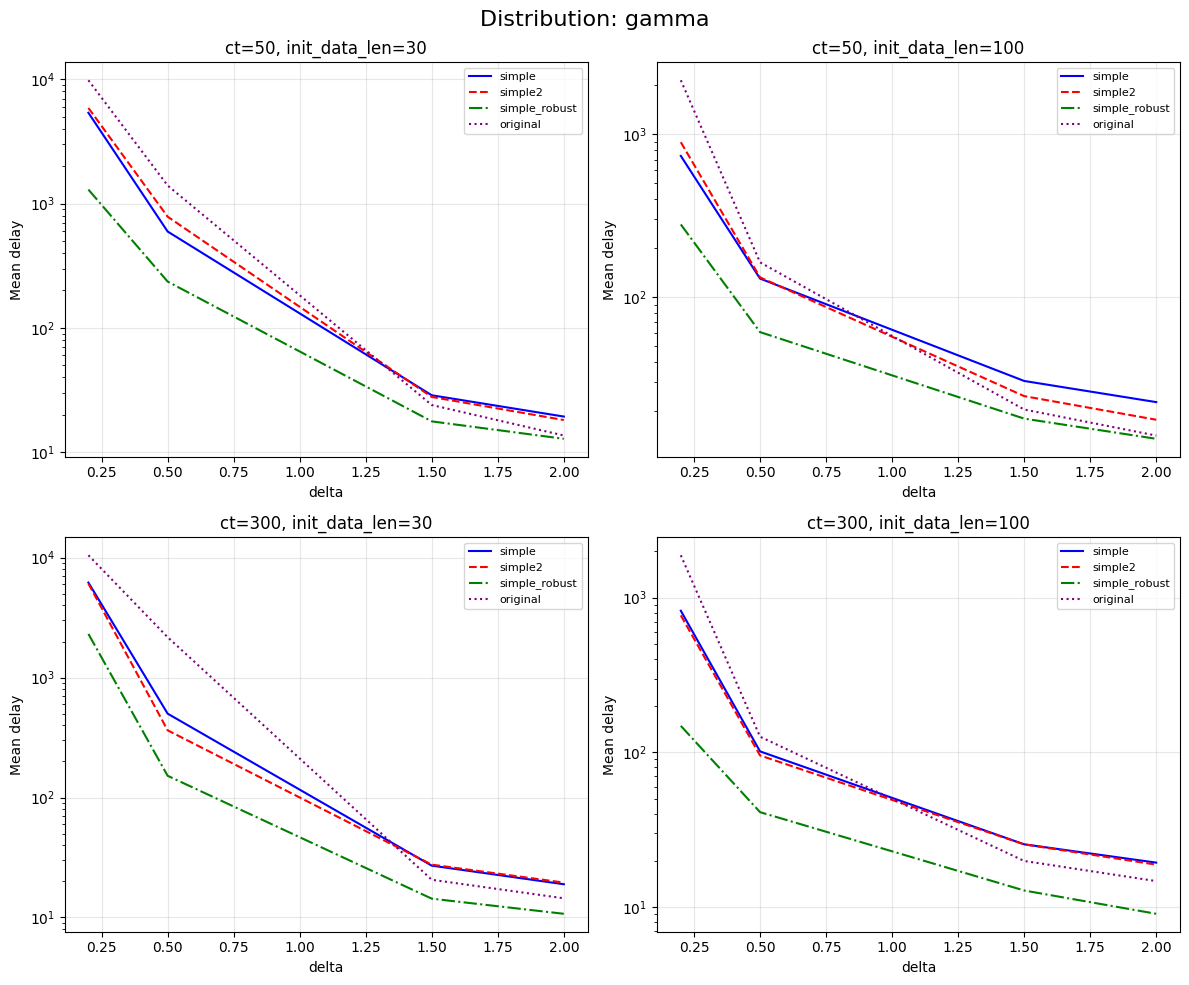

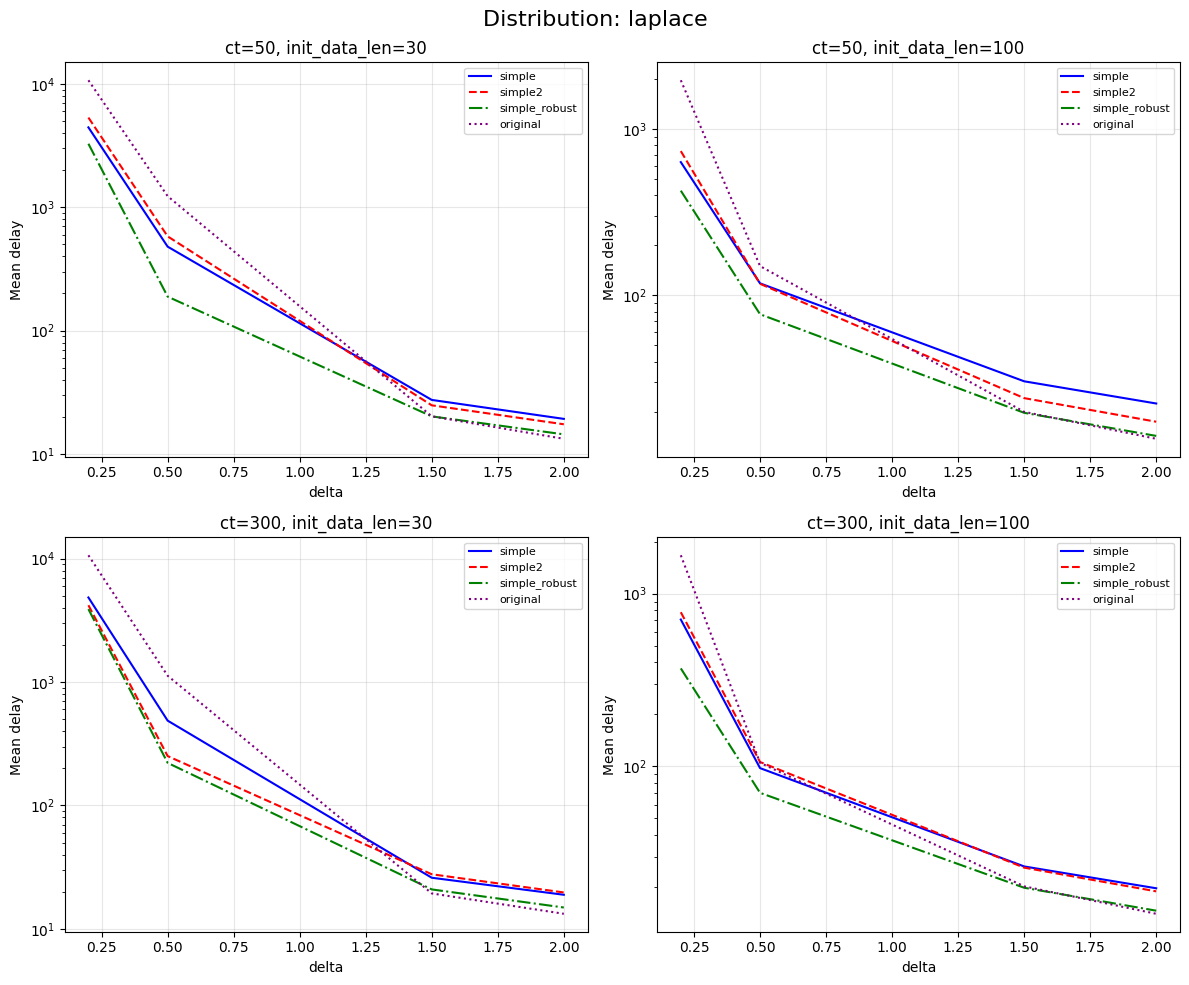

In [20]:
import matplotlib.pyplot as plt
import numpy as np

colors_methods = ['blue', 'red', 'green', 'purple']   # для simple, simple2, simple_robust, original
linestyles = ['solid', 'dashed', 'dashdot', 'dotted']
labels_methods = ['simple', 'simple2', 'simple_robust', 'original']

for dist_name in dists:
    data_dict = no_norm_delays_mean[dist_name]       # (len(ct), len(delta), len(idl), N)
    data2_dict = no_norm_delays_mean2[dist_name]
    data3_dict = no_norm_delays_mean3[dist_name]
    old_data_dict = no_norm_delays_mean_old[dist_name]

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'Distribution: {dist_name}', fontsize=16)

    for i, ct in enumerate(changetimes):
        for j, idl in enumerate(init_data_lens):
            ax = axes[i, j]

            data = data_dict[i, :, j, :]          # (len(deltas_mean), N)
            data2 = data2_dict[i, :, j, :]
            data3 = data3_dict[i, :, j, :]
            data_old = old_data_dict[i, :, j, :]

            mean_vals = np.mean(data, axis=1)
            mean_vals2 = np.mean(data2, axis=1)
            mean_vals3 = np.mean(data3, axis=1)
            mean_vals_old = np.mean(data_old, axis=1)


            ax.plot(deltas_mean, mean_vals,
                    color=colors_methods[0], linestyle=linestyles[0],
                    linewidth=1.5, label=labels_methods[0])
            ax.plot(deltas_mean, mean_vals2,
                    color=colors_methods[1], linestyle=linestyles[1],
                    linewidth=1.5, label=labels_methods[1])
            ax.plot(deltas_mean, mean_vals3,
                    color=colors_methods[2], linestyle=linestyles[2],
                    linewidth=1.5, label=labels_methods[2])
            ax.plot(deltas_mean, mean_vals_old,
                    color=colors_methods[3], linestyle=linestyles[3],
                    linewidth=1.5, label=labels_methods[3])

            ax.set_title(f'ct={ct}, init_data_len={idl}')
            ax.set_xlabel('delta')
            ax.set_ylabel('Mean delay')
            ax.set_yscale('log')
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(f"mean_delays_{dist_name}.png")
    plt.show()

#### End

In [15]:
# Для порядка сохраним все данные
np.savez(file="data.npz", **delays_mean)
np.savez(file="data2.npz", **delays_mean2)
np.savez(file="data3.npz", **delays_mean3)
np.savez(file="data_old.npz", **delays_mean_old)
np.savez(file="data_nochange.npz", **delays_mean_nochange)
np.savez(file="data2_nochange.npz", **delays_mean2_nochange)
np.savez(file="data3_nochange.npz", **delays_mean3_nochange)


np.savez(file="no_norm_data.npz", **no_norm_delays_mean)
np.savez(file="no_norm_data2.npz", **no_norm_delays_mean2)
np.savez(file="no_norm_data3.npz", **no_norm_delays_mean3)
np.savez(file="no_norm_data_old.npz", **no_norm_delays_mean_old)
np.savez(file="no_norm_data_nochange.npz", **no_norm_delays_mean_nochange)
np.savez(file="no_norm_data2_nochange.npz", **no_norm_delays_mean2_nochange)
np.savez(file="no_norm_data3_nochange.npz", **no_norm_delays_mean3_nochange)